<a href="https://colab.research.google.com/github/nathanlinjhu/Melanoma-Detection-Project/blob/main/TestMelanomaDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Test Accuracy: 93.15%

Correctly Classified Melanoma Images:


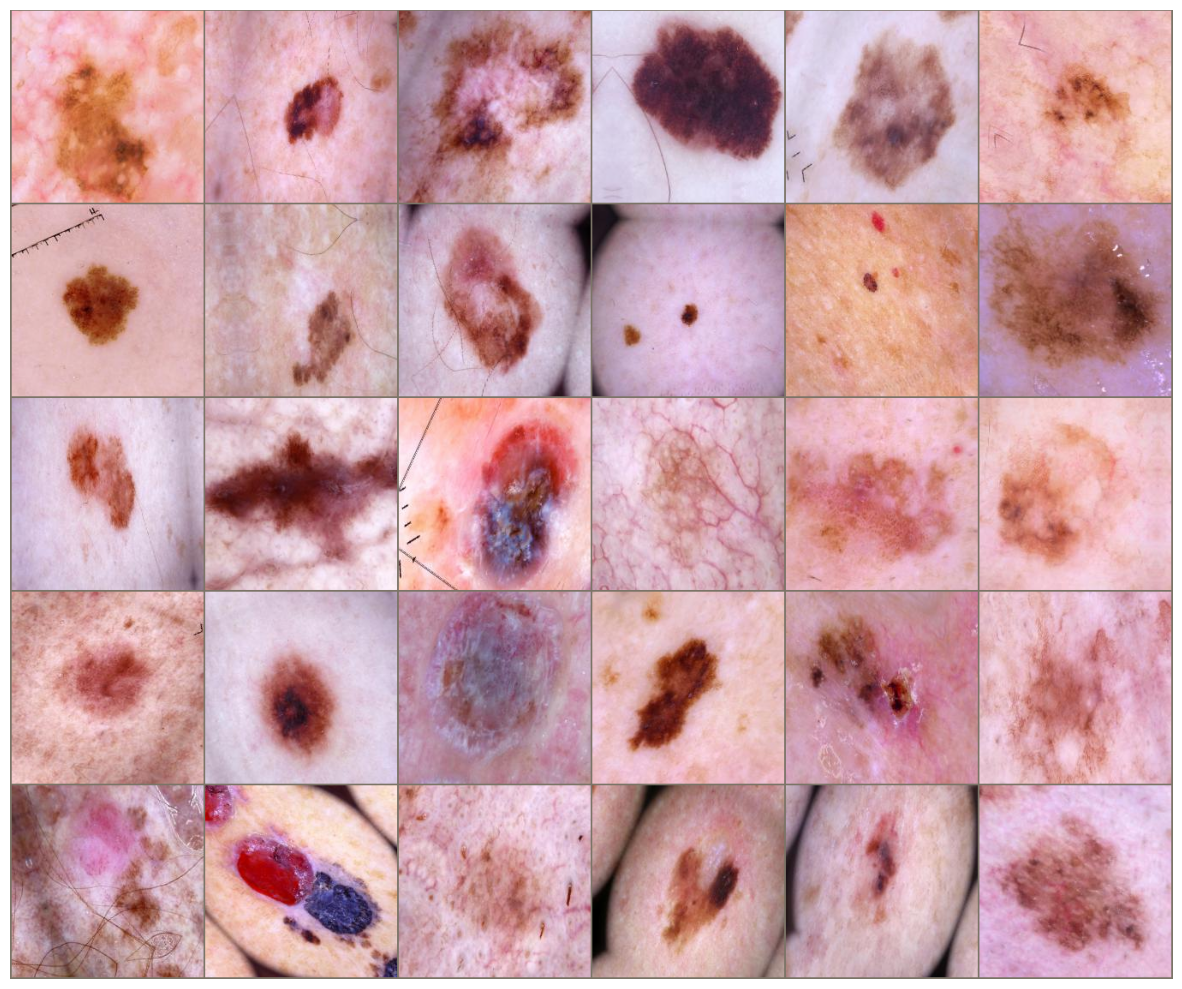


Correctly Classified NotMelanoma Images:


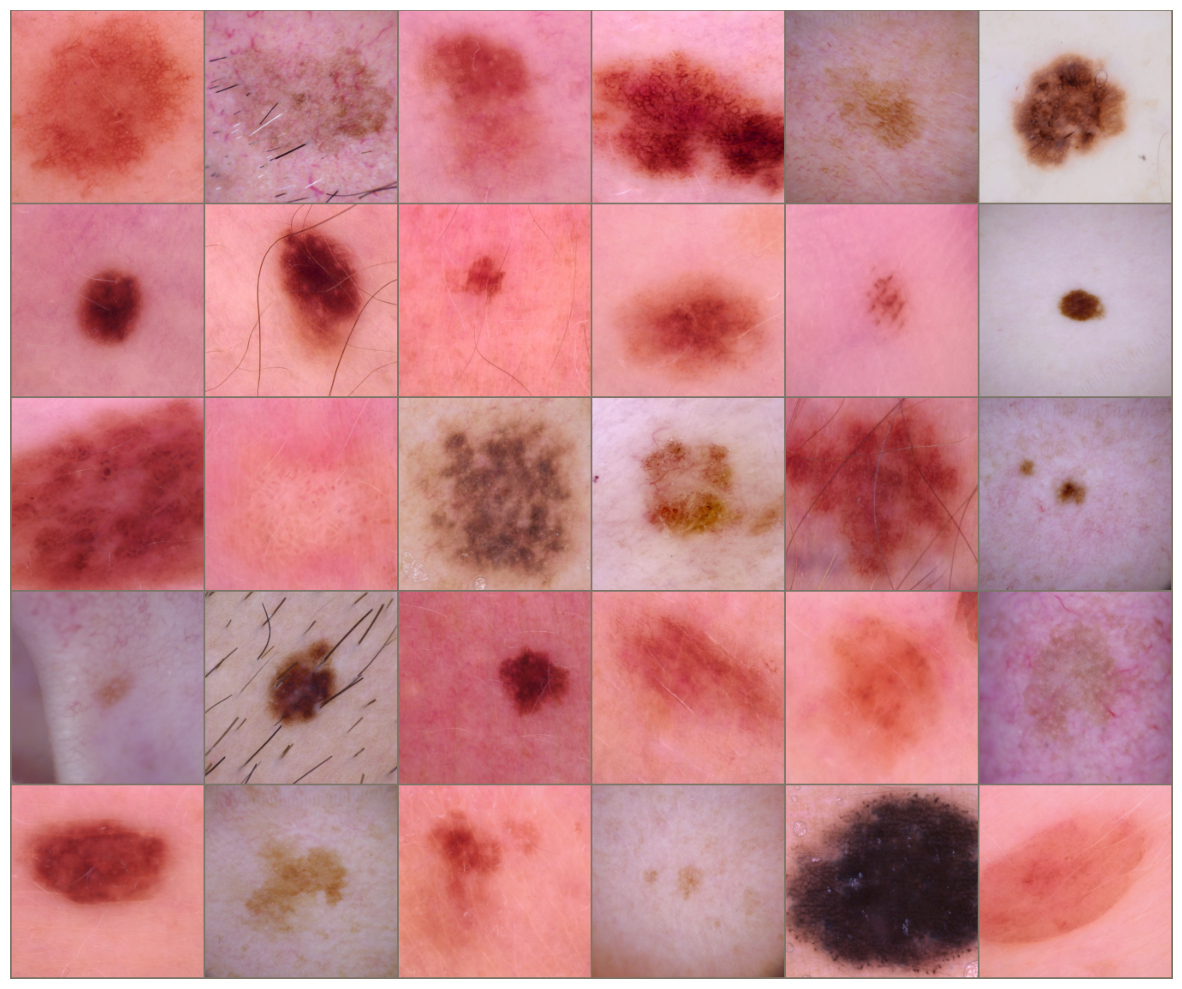

In [ ]:
# ---- 1. Set up device ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ---- 2. Load your model architecture ----
model = models.resnet50(pretrained=False)
num_features = model.fc.in_features
model.fc = torch.nn.Linear(num_features, 2) # 2 classes

# ---- 3. Load the trained weights (.pth file) ----
model.load_state_dict(torch.load('/content/drive/MyDrive/HEART Project Stelios Nathan/best_resnet50_melanoma.pth', map_location=device))
model.to(device)
model.eval()

# ---- 4. Specify class names, must match training order! ----
class_names = ['Melanoma', 'NotMelanoma']  # From train_dataset.classes or class_to_idx

# ---- 5. Image preprocessing (must match training) ----
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ---- 6. Load and transform your image ----
test_dataset  = datasets.ImageFolder('/content/drive/MyDrive/HEART Project Stelios Nathan/Melanoma Detection/Dataset/dermmel/DermMel/test', transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
test_correct = 0
test_total = 0
cnt = 0
correct_melanoma_images = []
correct_notmelanoma_images = []
melanoma_limit = 30
notmelanoma_limit = 30

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Store correctly classified images
        for i in range(len(labels)):
          if predicted[i] == labels[i]:
            if labels[i] == 0 and len(correct_melanoma_images) < melanoma_limit: # Melanoma
              correct_melanoma_images.append(images[i].cpu())
            elif labels[i] == 1 and len(correct_notmelanoma_images) < notmelanoma_limit: # NotMelanoma
              correct_notmelanoma_images.append(images[i].cpu())

test_acc = 100 * test_correct / test_total
print(f'Test Accuracy: {test_acc:.2f}%')

# ---- 7. Predict ----
"""
with torch.no_grad():
    output = model(input_tensor)
    _, predicted = torch.max(output, 1)
    idx = predicted.item()
    print(f'Predicted class: {class_names[idx]}')
"""

# ---- 8. Display correctly classified images ----
import matplotlib.pyplot as plt
import torchvision

def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')

import numpy as np

print("\nCorrectly Classified Melanoma Images:")
plt.figure(figsize=(15, 15))
if correct_melanoma_images:
    melanoma_grid = torchvision.utils.make_grid(correct_melanoma_images, nrow=6, padding=2)
    imshow(melanoma_grid)
    plt.show()
else:
    print("No correctly classified Melanoma images found within the limit.")


print("\nCorrectly Classified NotMelanoma Images:")
plt.figure(figsize=(15, 15))
if correct_notmelanoma_images:
    notmelanoma_grid = torchvision.utils.make_grid(correct_notmelanoma_images, nrow=6, padding=2)
    imshow(notmelanoma_grid)
    plt.show()
else:
    print("No correctly classified NotMelanoma images found within the limit.")